In [5]:
'''
Given probe entry/tip points and the waveform struct, estimate the antomical coordinates for each channel.

Input can be either a shape (3,) or shape (2,3) numpy array, depending on whether both probe tracks are visible.

If only 1 track is visible:
- the same ML/DV coords are assigned to each shank
- the AP coords are the track location +/- 1/2 the shank separation

Estimated anatomical location:
- ML relative to DM/DL bound
- AP est using hpc width and shank A/B
- DV using est depth and position on probe
'''
import numpy as np
import csv
import pandas as pd

import os 
import sys
sys.path.append("..//utils/")
sys.path.append("..//neural/")
import get_probe_coords
import format_waveform_data, waveform_analysis
import matplotlib.pyplot as plt

In [1]:
''' Set file paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"
save_figs = f"../figures/basic_neural_analysis/"

In [9]:
''' Load/create the dictionary of waveform data for all good stim sessions '''
# load or create data dictionary and get bird list
bird_ids = []
if os.path.isfile(data_file):
    data_dict = np.load(data_file, allow_pickle=True).item()
    for bird in data_dict.keys():
        bird_ids.append(bird)
    print(f'current birds with saved data: {bird_ids}')
    modify_dict = input("modify data dictionary? (y/n)")
    if modify_dict == 'y':
        data_dict = make_data_dict.modify_data_dict(root_dir, data_file)
else:
    data_dict = make_data_dict.modify_data_dict(root_dir, data_file)

# update bird list
for bird in data_dict.keys():
    if bird in bird_ids:
        continue
    else:
        bird_ids.append(bird)

current birds with saved data: ['LIM63', 'RBY94', 'AMB154', 'SLV132', 'IND67', 'LMN146']
modify data dictionary? (y/n)y


NameError: name 'make_data_dict' is not defined

In [7]:
# get the bird list
bird_list = []
for bird in data_dict.keys():
    bird_list.append(bird)

# load the session info for each bird
for bird in bird_list:
    session_list = data_dict[bird]['all_sessions']
    session_info = pd.read_excel(session_info_file, sheet_name=bird, header=1)
    session_info["id"] = session_info["date"].dt.strftime("%y%m%d")

    # get the approx probe depth per session
    for session_id in session_info['id']:
        if session_id in data_dict[bird].keys():
            # only calculate for new data
            if 'depth' in data_dict[bird][session_id].keys():
                continue
            probe_depth = session_info.loc[session_info["id"] == session_id,
                                           "approx. depth (um)"].iloc[0]
            data_dict[bird][session_id]['depth'] = probe_depth

    # to store the insertion coordinates - ML, AP, angle for each shank
    data_dict[bird]['insert_coords'] = np.zeros((2, 3))

# grab the raw coordinates
for i, row in probe_info.iterrows():
    # get the bird and shank IDs
    bird_shank = row['bird ID']
    bird, shank = bird_shank.split(sep='_')

    # extract the raw coords
    rel_ml = row['ML']
    rel_ap = row['AP']
    angle_deg = row['angle_deg']

    # store the raw values
    insert_coords = np.asarray([rel_ml, rel_ap, angle_deg])
    if shank=='A':
        data_dict[bird]['insert_coords'][0] = insert_coords
    else:
        data_dict[bird]['insert_coords'][1] = insert_coords

# convert the relative coords to absolute
for bird in bird_list:
    raw_coords = data_dict[bird]['insert_coords']
    abs_coords = convert_coords(raw_coords)
    data_dict[bird]['insert_coords'] = abs_coords 

AttributeError: Can only use .dt accessor with datetimelike values

In [8]:
bird

'IND67'

In [6]:
''' Get the cell positions for each ephys session '''
# ensure the probe info is up to date
data_dict = get_probe_coords.get_anatomy_info(session_info_file, data_dict)

all_cell_pos = []
for bird in bird_ids:
    print(f'\nlocalizing cells for {bird}')
    insert_coords = data_dict[bird]['insert_coords']
    session_list = data_dict[bird]['all_sessions']
    for session_id in session_list:
        # specify the file paths
        if 'ephys' in data_dict[bird][session_id]['preprocessed_data']:
            session_dir = f'{root_dir}{bird}/{bird}_{session_id}/'
            for folder in os.listdir(session_dir):
                if f'{bird}_{session_id}' in folder:
                    ephys_id = folder[-13:]
            for file in os.listdir(f"{session_dir}{bird}_{ephys_id}"):
                if 'kilosort4' in file:
                    ks_dir = f"{bird}_{ephys_id}/{file}/"
                    ephys_dir = f"{session_dir}{bird}_{ephys_id}/raw_ephys_output/"

                    # get the cell positions
                    depth = data_dict[bird][session_id]['depth']
                    cell_pos = get_probe_coords.get_cell_pos(session_dir, ks_dir, ephys_dir, insert_coords, depth)
                    data_dict[bird][session_id]['cell_pos'] = cell_pos

                    # collect all the possitions
                    if len(all_cell_pos) == 0:
                        all_cell_pos = cell_pos
                    else:
                        all_cell_pos = np.row_stack(all_cell_pos, cell_pos)

AttributeError: Can only use .dt accessor with datetimelike values

In [27]:
''' inputs '''
# bird ID
bird = 'LIM63'

# insertion data
insert_angle = 10 # degrees
insert_angle_rad = np.deg2rad(insert_angle)
insert_coords = np.asarray([0.24, 0.91, 0])*1000 # ML, AP, DV

In [28]:
insert_coords

array([240., 910.,   0.])

In [30]:
# set file paths
root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs = f"../figures/targeting/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"

# load the data dict and get the session IDs
data_dict = np.load(data_file, allow_pickle=True).item()
session_list = data_dict[bird]['all_sessions']

In [31]:
''' probe coordinates in the brain (ML, AP, DV) '''
# load the session info for this bird
session_info = pd.read_excel(session_info_file, sheet_name=bird, header=1)
session_info["id"] = session_info["date"].dt.strftime("%y%m%d")

# get the approx probe depth per session
for session_id in session_info['id']:
    if session_id in data_dict[bird].keys():
        probe_depth = session_info.loc[session_info["id"] == session_id,
                                       "approx. depth (um)"].iloc[0]
        data_dict[bird][session_id]['depth'] = probe_depth
        
        # estimate the tip location
        tip_ml = insert_coords[0] - probe_depth*np.sin(insert_angle)
        tip_ap = insert_coords[1]
        tip_dv = -probe_depth*np.cos(insert_angle)
        data_dict[bird][session_id]['tip_coords'] = np.asarray([tip_ml, tip_ap, tip_dv])

In [9]:
# get probe insertion coordinates for all birds
probe_info = pd.read_excel(session_info_file, sheet_name='Anatomy', header=0)

In [12]:
# get the bird list
bird_list = []
for bird in data_dict.keys():
    bird_list.append(bird)

In [20]:
# to store the coordinates - ML, AP, angle for each shank
for bird in bird_list:
    data_dict[bird]['insert_coords'] = np.zeros((2, 3))

# grab the raw coordinates
for i, row in probe_info.iterrows():
    # get the bird and shank IDs
    bird_shank = row['bird ID']
    bird, shank = bird_shank.split(sep='_')
    
    # extract the raw coords
    rel_ml = row['ML']
    rel_ap = row['AP']
    angle_deg = row['angle_deg']
    
    # convert and store
    insert_coords = convert_coords(np.asarray([rel_ml, rel_ap, angle_deg]))
    if shank=='A':
        data_dict[bird]['insert_coords'][0] = insert_coords
    else:
        data_dict[bird]['insert_coords'][1] = insert_coords

In [21]:
data_dict[bird]['insert_coords']

array([[1.12      , 1.41      , 0.19198622],
       [0.99      , 1.2       , 0.19198622]])

In [19]:
def convert_coords(raw_coords):
    '''
    Takes the raw coordinates and converts them to a more useful format
    
    Converts relative ML/AP values to absolute (lamda-oriented) values
    Converts degrees to radians
    '''
    rel_ml = raw_coords[0]
    rel_ap = raw_coords[1]
    angle_deg = raw_coords[2]
    
    # adjust ml
    abs_ml = rel_ap - rel_ml
    
    # adjust ap - todo
    abs_ap = rel_ap
    
    # convert degrees to radians
    angle_rad = np.deg2rad(angle_deg)
    
    return np.asarray([abs_ml, abs_ap, angle_rad])

In [133]:
def probe_to_brain(tip_coords, probe_coords, insert_angle_deg=10):
    '''
    Given a probe that is tilted towards the midline and not tilted in the AP axis,
    convert from probe coordinates (as output by kilosort) to brain coordinates.
    
    Params
    ------
    tip_coords : nparray, shape (3,)
        ML, AP, and DV coordinates of the probe tip in the brain
    insert_angle_deg : float
        angle of probe insertion (relative to the midline) in degrees
    probe_coords : nparray, shape (n_channels, 2)
        AP and DV coordinates along the probe
        
    Returns
    -------
    brain_coords : nparray, shape (n_channels, 3)
        ML, AP, and DV coordinates in the brain
    '''
    # format inputs
    insert_angle_rad = np.deg2rad(insert_angle_deg)
    tip_ml, tip_ap, tip_dv = tip_coords
    probe_ap = probe_coords[:, 0]
    probe_dv = probe_coords[:, 1]  
    
    # convert
    brain_ml = tip_ml - probe_dv * np.sin(insert_angle_rad)
    brain_ap = tip_ap - probe_ap
    brain_dv = tip_dv - probe_dv * np.cos(insert_angle_rad)
    
    return np.column_stack((brain_ml, brain_ap, brain_dv))

In [134]:
''' load the waveform info and get each channel's position on the probe '''
for session_id in session_list:
    # specify the file paths
    if 'ephys' in data_dict[bird][session_id]['preprocessed_data']:
        session_dir = f'{root_dir}{bird}/{bird}_{session_id}/'
        for folder in os.listdir(session_dir):
            if f'{bird}_{session_id}' in folder:
                ephys_id = folder[-13:]
        for file in os.listdir(f"{session_dir}{bird}_{ephys_id}"):
            if 'kilosort4' in file:
                ks_dir = f"{bird}_{ephys_id}/{file}/"
                ephys_dir = f"{session_dir}{bird}_{ephys_id}/raw_ephys_output/"

                # load and format the waveform struct
                waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
                wf_ids = waveform_struct['goodIDs']
                mean_waveforms, wf_channels, _, ch_names = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                                   data_dir=ephys_dir,
                                                                                                   return_ch_names=True)       
                n_cells = mean_waveforms.shape[0]
                wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])

                # load the channel positions and convert to brain coords
                ch_pos_probe = np.load(f"{session_dir}{ks_dir}channel_positions.npy")
                tip_coords = data_dict[bird][session_id]['tip_coords']
                ch_pos_brain = probe_to_brain(tip_coords=tip_coords,
                                              probe_coords=ch_pos_probe,
                                              insert_angle_deg=insert_angle)

                # get the position of each cell in the brain
                cell_pos = np.zeros((n_cells, 3))
                for cell, ch in enumerate(wf_ch_idx):
                    cell_pos[cell] = ch_pos_brain[ch]
                data_dict[bird][session_id]['cell_pos'] = cell_pos

Z:/Isabel/data/hpc_implants/SLV132/SLV132_250303/SLV132_250303_100940/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/SLV132/SLV132_250303/SLV132_250303_100940/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/SLV132/SLV132_250318/SLV132_250318_103512/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/SLV132/SLV132_250318/SLV132_250318_103512/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/SLV132/SLV132_250320/SLV132_250320_104847/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/SLV

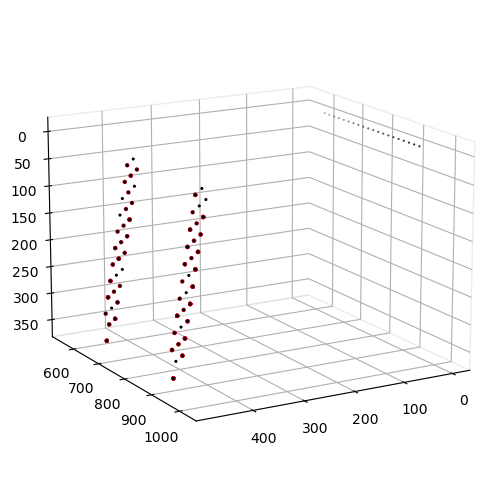

In [136]:
fig = plt.figure(figsize=(8, 4))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')

# plot cell positions
ax.scatter(cell_pos[:, 0], cell_pos[:, 1], cell_pos[:, 2],
           c='xkcd:scarlet', s=10, lw=0, zorder=1, alpha=1)
ax.scatter(ch_pos_brain[:, 0], ch_pos_brain[:, 1], ch_pos_brain[:, 2],
           c='k', s=5, lw=0, zorder=0, alpha=1)

# plot DM/DL boundary
n_dashes = 20
y_lims = ax.get_ylim()
dmdl_bound = np.linspace(y_lims[0], y_lims[1], n_dashes)
ax.scatter(np.zeros(n_dashes), dmdl_bound, np.zeros(n_dashes),
           c='k', marker='.', s=1)

# set axis limits
ax.axis('equal')
z_lims = ax.get_zlim()
ax.set_zlim(z_lims[1], z_lims[0])
# ax.set_ylim(y_lims[1], y_lims[0])

# background color
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('xkcd:grey')
ax.yaxis.pane.set_edgecolor('xkcd:grey')
ax.zaxis.pane.set_edgecolor('xkcd:grey')
ax.xaxis.pane.set_color('xkcd:light grey')
ax.yaxis.pane.set_color('xkcd:light grey')
ax.zaxis.pane.set_color('xkcd:light grey')

ax.view_init(azim=60, elev=15)
ax.set_box_aspect(aspect=None, zoom=1)
plt.show()

In [23]:
all_cell_pos = []
len(all_cell_pos)

0

In [ ]:
'''
TODO:
conversion functions
- AP (hpc width) to approx AP in brain
- ML (dist to DM/DL bounc) to approx ML in brain (given hpc width)

rotation function (see below)

DM/DL boundary coords for plotting purposes
--> using AP conversion
'''

In [46]:
'''
Consider the (real-world) case that the probe is also tilted in the AP axis
In this case, we need to rotate the points in 3D

TODO:
Because ML is relative to the DM/DL boundary, this value also needs to be adjusted
(e.g., if the channel is 100um A of the tip, the DM/DL boundary is 100um M of where it was in the tip slice)

Update the ChatGPT code below
'''
def channel_to_brain_coords(tip_xyz, channel_yz, angle_x_deg=0, angle_y_deg=0):
    """
    Convert channel coordinates relative to electrode tip into absolute
    brain coordinates, allowing tilt in both x-z and y-z planes.

    Parameters
    ----------
    tip_xyz : tuple of float
        Electrode tip location (x, y, z).
    channel_yz : array-like, shape (n, 2)
        Local channel coordinates [(y_, z_), ...] relative to the tip.
        Each point is treated as local (0, y_, z_).
    angle_x_deg : float
        Tilt in the x-z plane (rotation about y-axis).
    angle_y_deg : float
        Tilt in the y-z plane (rotation about x-axis).

    Returns
    -------
    coords : ndarray, shape (n, 3)
        Absolute channel coordinates [(x, y, z), ...].
    """
    x0, y0, z0 = tip_xyz
    channel_yz = np.asarray(channel_yz, dtype=float)

    y_rel = channel_yz[:, 0]
    z_rel = channel_yz[:, 1]

    # Local coordinates: x_local = 0
    pts_local = np.column_stack([
        np.zeros(len(channel_yz)),
        y_rel,
        z_rel
    ])

    ax = np.deg2rad(angle_x_deg)
    ay = np.deg2rad(angle_y_deg)

    # Rotation about y-axis: tilt in x-z plane
    Ry = np.array([
        [ np.cos(ax), 0, np.sin(ax)],
        [ 0,          1, 0         ],
        [-np.sin(ax), 0, np.cos(ax)]
    ])

    # Rotation about x-axis: tilt in y-z plane
    Rx = np.array([
        [1, 0,           0          ],
        [0, np.cos(ay), -np.sin(ay)],
        [0, np.sin(ay),  np.cos(ay)]
    ])

    # Apply x-z tilt first, then y-z tilt
    R = Rx @ Ry

    pts_global = pts_local @ R.T
    pts_global += np.array([x0, y0, z0])

    return pts_global

330.0